In [1]:
from gradio_client import Client   # for api use

import ast                         # for text to list conversion (make data useful)
import pandas as pd                # for easy data use; you can use polars or whatever you like

# start 8:14pm

# Accessing the API

Accessing the API is simple. You pass your key to the client, and then you will see a message the API has loaded.

In [2]:
token = '../api_creds/vi_key_1.csv'

# load my key
df = pd.read_csv(token) # easy and lazy lol; using pandas anyway ;p
api_key = df['key'][0]  # easy and lazy lol; using pandas anyway ;p

# connect to api
client = Client("verdantintel/gsv3", token=api_key)

Loaded as API: https://verdantintel-gsv3.hf.space


# Helper Function

In [3]:
def parse_events(text):

    events = []

    for block in text.strip().split("\n\n"):
        lines = block.split("\n")

        event = {"title": lines[0].strip()}

        for line in lines[1:]:
            if ":" in line:
                key, value = line.split(":", 1)
                key = key.strip().lower().replace(" ", "_")
                value = value.strip()
                event[key] = value

        events.append(event)

    return events

In [4]:
def ask_api(client, question):

    answer = client.predict(question=question, api_name="/predict")
    
    #answer = ast.literal_eval(answer)
    events = parse_events(answer)

    return events

    #return answer

# Searching for Data

In [7]:
question = 'what punk shows happen in Portland?'

answer = ask_api(client, question)
len(answer)

124

In [8]:
answer[0]

{'title': 'TEENAGE BOTTLEROCKET with Tightwire, Broadway Calls, & Old Cross',
 'performers': 'TEENAGE BOTTLEROCKET, Tightwire, Broadway Calls, Old Cross',
 'event_dates': '25 April 8:00 PM PDT',
 'price': 'Not provided in source.',
 'venue': "Dante's",
 'location': '350 West Burnside Street, Portland, OR 97209',
 'contact_information': 'Not provided in source.',
 'description': "TEENAGE BOTTLEROCKET will be performing live at Dante's alongside Tightwire, Broadway Calls, and Old Cross.",
 'genres': 'Punk, Pop',
 'source_url': 'https://www.ticketweb.com/event/teenage-bottlerocket-with-tightwire-broadway-dantes-tickets/14122744'}

# Going Out Methodology

- Fetch GrooveSeeker events (done)
- Read quickly with my eyes looking for interesting things
- Reduce to a few options that I am actually interest in
- Go have fun

The test of GrooveSeeker is whether or not it leads to things that I enjoy. The technical tests are already done.

In [11]:
answer[0:2]

[{'title': 'TEENAGE BOTTLEROCKET with Tightwire, Broadway Calls, & Old Cross',
  'performers': 'TEENAGE BOTTLEROCKET, Tightwire, Broadway Calls, Old Cross',
  'event_dates': '25 April 8:00 PM PDT',
  'price': 'Not provided in source.',
  'venue': "Dante's",
  'location': '350 West Burnside Street, Portland, OR 97209',
  'contact_information': 'Not provided in source.',
  'description': "TEENAGE BOTTLEROCKET will be performing live at Dante's alongside Tightwire, Broadway Calls, and Old Cross.",
  'genres': 'Punk, Pop',
  'source_url': 'https://www.ticketweb.com/event/teenage-bottlerocket-with-tightwire-broadway-dantes-tickets/14122744'},
 {'title': 'Avalanche Lily & Gregory James McKillop / Ruune',
  'performers': 'Avalanche Lily, Gregory James McKillop aka Ruune',
  'event_dates': 'Saturday, February 28, 7–9 pm',
  'price': 'Free',
  'venue': 'The Chinese Cowboy',
  'location': '727 SE Washington Street, Portland, OR 97214',
  'contact_information': 'Not provided in source.',
  'descr

Let's loop through titles and see what looks interesting. I don't want to be distracted by the other context yet. Title and descriptiona re good enough.

In [12]:
df = pd.DataFrame(answer)

df = df[df['source_url'].str.startswith('https')] # simple URL filter; drop empties; the rest are https

df.drop_duplicates(inplace=True)
df.sort_values('title', inplace=True)

for row in df.iterrows():
    
    title = row[1]['title']
    description = row[1]['description']
    event_dates = row[1]['event_dates']
    
    url = row[1]['source_url']
    
    print(title)
    print()
    print(event_dates)
    print()
    print(description)
    print()
    print(url)
    print()
    print('-------------------------------------------------')
    print()

A WILHELM SCREAM with Death By Stereo & Doomsday

Thursday, February 26, 8:30 PM

A Wilhelm Scream is performing with Death By Stereo and Doomsday at Dante's. The band brings a collection of songs from their new album "Lose Your Delusion," showcasing a mix of punk rock and emotional themes.

https://everout.com/portland/events/a-wilhelm-scream-with-death-by-stereo-doomsday/e223018/

-------------------------------------------------

AGENT ORANGE with The Drowns & Guests

Saturday, 20 June 2026, 9:00 PM PDT

Agent Orange, a pioneer of the Southern California Punk/Surf scene, combines melodic California surf guitar with punk energy. The band has influenced many and continues to perform internationally, appealing to a loyal following.

https://www.ticketweb.com/event/agent-orange-with-the-drowns-dantes-tickets/14126774

-------------------------------------------------

Advisory, Pleb_Talk, Squandry

Sunday, March 15, 7–11 pm

This event features live music performances by the bands Advis

Since writing the article, I often come back to this notebook to look up fun events. 

I used a similar notebook to go to a show: https://100daysofnetworks.substack.com/p/day-81-of-100daysofnetworks
I will use this to find more bands and shows

# Data Science Exploration

This time, I wanna go a bit further and see what I can do. I wonder if I can use bipartite projection
to learn more about the ecosystem, but converting this into a social graph and a venue graph.

In [43]:
# for graph
import networkx as nx

# for bipartite projection
from networkx.algorithms import bipartite

# for visualization
import numpy as np
from IPython.display import SVG 
from sknetwork.visualization import svg_graph 
from sknetwork.data import Bunch 
from sknetwork.ranking import PageRank 
from scipy.sparse import csr_matrix

def draw_graph(G, show_names=True, node_size=5, font_size=10, edge_width=1, scores=True):

    adjacency = nx.to_scipy_sparse_array(G, nodelist=None, dtype=None, weight='weight', format='csr')
    adjacency = csr_matrix(adjacency) # fix to weird sknetwork-csr issue; comment out to troubleshoot
    
    names = np.array(list(G.nodes))
    
    graph = Bunch()
    graph.adjacency = adjacency
    graph.names = np.array(names)
    
    pagerank = PageRank()
    scores = pagerank.fit_transform(adjacency)

    if show_names:
        
        image = svg_graph(graph.adjacency, font_size=font_size, node_size=node_size, names=graph.names, width=700, height=500, scores=scores, edge_width=edge_width)
    
    else:
        
        image = svg_graph(graph.adjacency, node_size=node_size, width=700, height=500, scores=scores, edge_width=edge_width)
    
    return SVG(image)

In [44]:
edgelist_df = df[['performers', 'venue']].copy()
edgelist_df['performers'] = edgelist_df['performers'].apply(lambda s: s.split(','))
edgelist_df = edgelist_df.explode('performers')
edgelist_df.head()

,performers,venue
55,A Wilhelm Scream,Dante's
55,Death By Stereo,Dante's
55,Doomsday,Dante's
11,AGENT ORANGE,Dante's
11,The Drowns,Dante's


# Bipartite Projection: Social Network

First, I will create a bipartite graph and then convert it into a social network.

In [58]:
B = nx.from_pandas_edgelist(edgelist_df, source='performers', target='venue')
G_artists = bipartite.projected_graph(B, edgelist_df['performers'])

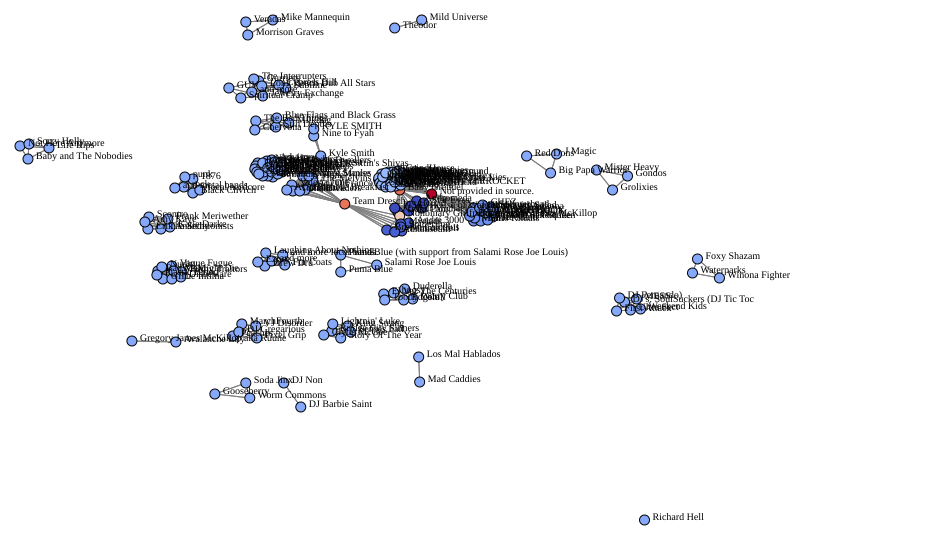

In [59]:
draw_graph(G_artists)

In [63]:
sorted(G_artists.nodes) # Artists that are related to Punk Rock and pass through Portland, Oregon

[' 1876',
 ' Acid Bath',
 ' Adnauseum',
 ' Amy Beth & thee Creeps',
 ' Amy Kaye',
 ' Attention Earth Dwellers',
 ' Baby Grendel',
 ' Baby and The Nobodies',
 ' Big Papa Warrior',
 ' Blister',
 ' Blue Flags and Black Grass',
 ' Broadway Calls',
 ' Brown Calculus',
 ' CHEZ',
 ' Chervona',
 ' Clyde McGee',
 ' Cypress Hill',
 ' DJ Fernando)',
 " DJ's: SoulSuckers (DJ Tic Toc",
 ' Death By Stereo',
 ' Disbeware',
 ' Dismantle Me',
 ' Doom Scroll',
 ' Doomsday',
 ' Dream Theory',
 ' Drew Dru',
 ' Duderella',
 ' Dystoria',
 ' Edgehill',
 ' Erik Anarchy',
 ' Eznce',
 ' Femme Cell',
 ' Filthy Traitors',
 ' First Attack',
 ' Foxy Shazam',
 ' Frank Meriwether',
 ' Friends with Salad',
 ' GFL',
 ' Girls Rituals',
 ' Gravure',
 ' Gregory James McKillop aka Ruune',
 ' GrindHouse',
 ' Grolixies',
 ' Himalayas',
 ' Hopeless Jack',
 ' Hound',
 ' House of Warmth',
 ' J Magic',
 ' Japanese Breakfast',
 ' Jet Hag',
 ' Jewelry Exchange',
 ' Karen Caskets',
 ' Keep Flying',
 ' Kill Michael',
 ' King Strang'

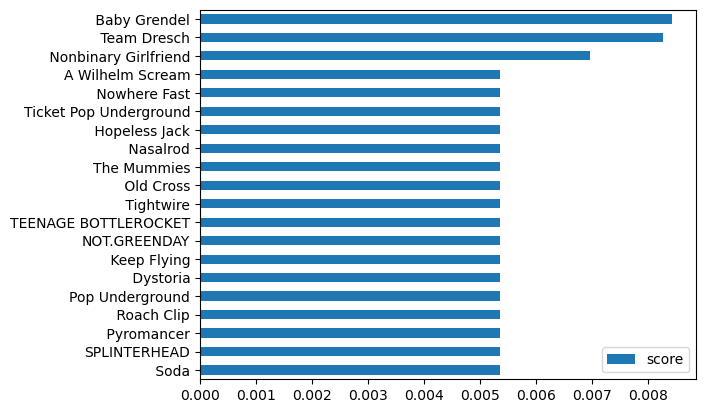

In [75]:
score_df = pd.DataFrame([nx.pagerank(G_artists)]).T
score_df.columns = ['score']
score_df.sort_values('score', ascending=False, inplace=True)
score_df = score_df[1:]
score_df.head(20).plot.barh().invert_yaxis()

# Bipartite Projection: Social Network

Next, I will create a bipartite graph and then convert it into a venue network.

This shows that looking at things from different perspectives can be interesting.

It's the same bipartite graph looked at from a different perspective.

In [64]:
B = nx.from_pandas_edgelist(edgelist_df, source='performers', target='venue')
G_venue = bipartite.projected_graph(B, edgelist_df['venue'])

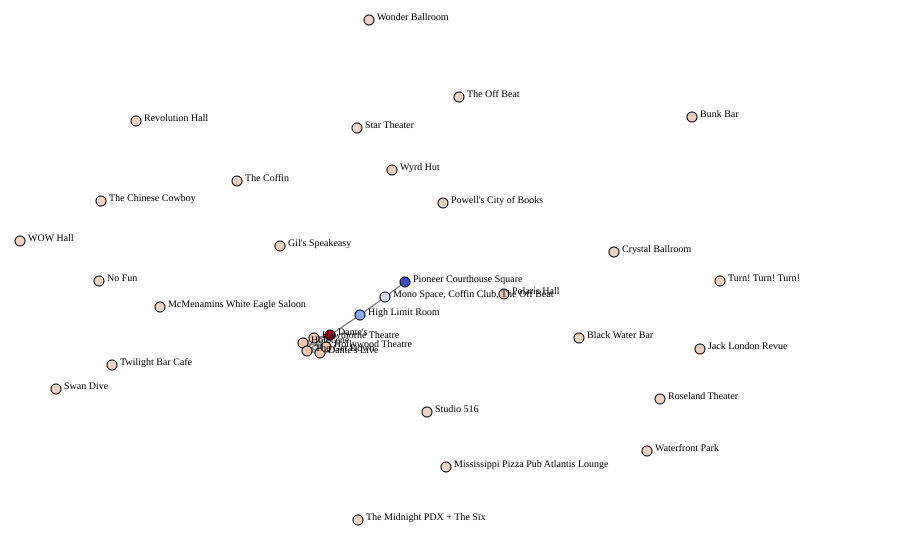

In [65]:
draw_graph(G_venue)

In [66]:
sorted(G_venue.nodes) # Artists that are related to Punk Rock and pass through Portland, Oregon

['Black Water Bar',
 'Bunk Bar',
 'Crystal Ballroom',
 "Dante's",
 "Dante's Live",
 "Gil's Speakeasy",
 'Hawthorne Theatre',
 'High Limit Room',
 'Hollywood Theatre',
 'Holocene',
 'Jack London Revue',
 'McMenamins White Eagle Saloon',
 'Mississippi Pizza Pub & Atlantis Lounge',
 'Mono Space, Coffin Club, The Off Beat',
 'No Fun',
 'Pioneer Courthouse Square',
 'Polaris Hall',
 "Powell's City of Books",
 'Revolution Hall',
 'Roseland Theater',
 'Star Theater',
 'Studio 516',
 'Swan Dive',
 'The Chinese Cowboy',
 'The Coffin',
 'The Get Down',
 'The Midnight PDX + The Sïx',
 'The Off Beat',
 'Turn! Turn! Turn!',
 'Twilight Bar & Cafe',
 'WOW Hall',
 'Waterfront Park',
 'Wonder Ballroom',
 'Wyrd Hut']

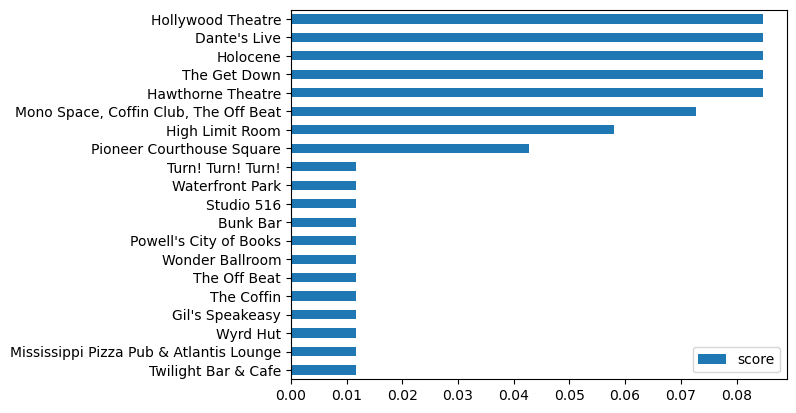

In [76]:
score_df = pd.DataFrame([nx.pagerank(G_venue)]).T
score_df.columns = ['score']
score_df.sort_values('score', ascending=False, inplace=True)
score_df = score_df[1:]
score_df.head(20).plot.barh().invert_yaxis()

# I guess I should check these places out!

# Next Steps

Learn more! Listen to the bands on Youtube and other platforms and find bands that you enjoy. Look up information about vanues, and then go to them to see what you like.